   Income  Kidhome  Teenhome  MntWines  MntFruits  MntMeatProducts  \
0   58138        0         0       635         88              546   
1   46344        1         1        11          1                6   
2   71613        0         0       426         49              127   
3   26646        1         0        11          4               20   
4   58293        1         1       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  NumWebPurchases  \
0              172                88            88                8   
1                2                 1             6                1   
2              111                21            42                8   
3               10                 3             5                2   
4               46                27            15                5   

   NumStorePurchases  Response  
0                  4         1  
1                  2         0  
2                 10         1  
3                  4

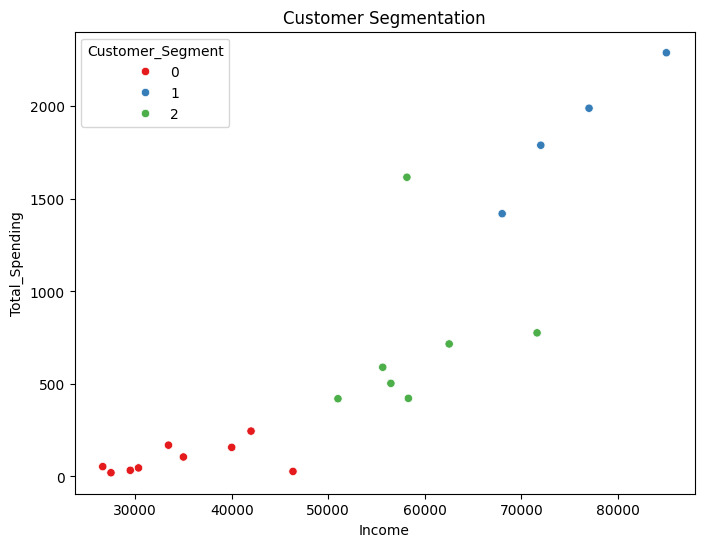


Random Forest Accuracy:
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 332.3429 - val_accuracy: 0.5000 - val_loss: 23.5209
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5000 - loss: 25.2908 - val_accuracy: 0.5000 - val_loss: 102.6325
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5000 - loss: 98.1931 - val_accuracy: 0.5000 - val_loss: 85.1625
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5000 - loss: 81.3272 - val_accuracy: 0.5000 - val_loss: 11.8554
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5000 - loss: 14.4611 - val_accuracy: 0.5000 - val_loss: 37.5308
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5000 - loss: 35.3900 - val_accuracy: 0.5000 - val_loss: 19.8984
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5000 - loss: 18.3669 - val_accuracy: 0.5000 - val_loss: 74.0274
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5000 - loss: 76.8259 - val_accuracy: 0.5000 - val_loss: 17

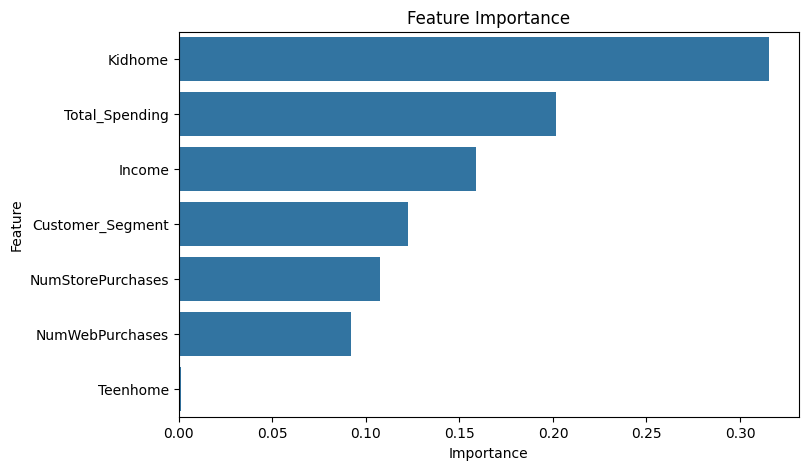

In [1]:
# ==========================================
# CUSTOMER PERSONALITY & PURCHASE PREDICTION
# SUPERVISED + UNSUPERVISED + NEURAL NETWORK
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("customer_personality.csv")

print(df.head())
print(df.info())

# ==========================================
# DATA CLEANING
# ==========================================

df = df.dropna()

# Convert categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# ==========================================
# FEATURE ENGINEERING
# ==========================================

df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

# ==========================================
# UNSUPERVISED LEARNING
# CUSTOMER SEGMENTATION
# ==========================================

cluster_features = [
    'Income',
    'Total_Spending',
    'NumWebPurchases',
    'NumStorePurchases'
]

X_cluster = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)

df['Customer_Segment'] = kmeans.fit_predict(X_scaled)

print("\nCustomer Segments:")
print(df['Customer_Segment'].value_counts())

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Income'],
    y=df['Total_Spending'],
    hue=df['Customer_Segment'],
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.show()

# ==========================================
# SUPERVISED LEARNING
# PURCHASE RESPONSE PREDICTION
# ==========================================

target = 'Response'

features = [
    'Income',
    'Kidhome',
    'Teenhome',
    'Total_Spending',
    'NumWebPurchases',
    'NumStorePurchases',
    'Customer_Segment'
]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# RANDOM FOREST
# ==========================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

# ==========================================
# NEURAL NETWORK
# ==========================================

nn = Sequential()

nn.add(Dense(64, activation='relu',
             input_shape=(X_train.shape[1],)))

nn.add(Dense(32, activation='relu'))

nn.add(Dense(1, activation='sigmoid'))

nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = nn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ==========================================
# EVALUATION
# ==========================================

loss, acc = nn.evaluate(X_test, y_test)

print("\nNeural Network Accuracy:")
print(acc)

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()